# Median Income Distribution for Porto

This notebook creates a hexagonal grid representation of the median income distribution across Portuguese cities' freguesias. The output will follow the same standard format.

In [1]:
# Install required packages if needed
# !pip install geopandas osmnx folium minisom numpy matplotlib shapely pyproj

In [ ]:
# Import required libraries
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import json
from verus.grid import HexagonGridGenerator

/Volumes/Hercules/Developer/multilayer-priority/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Load the municipality boundary

In [18]:
city = "Lisbon"

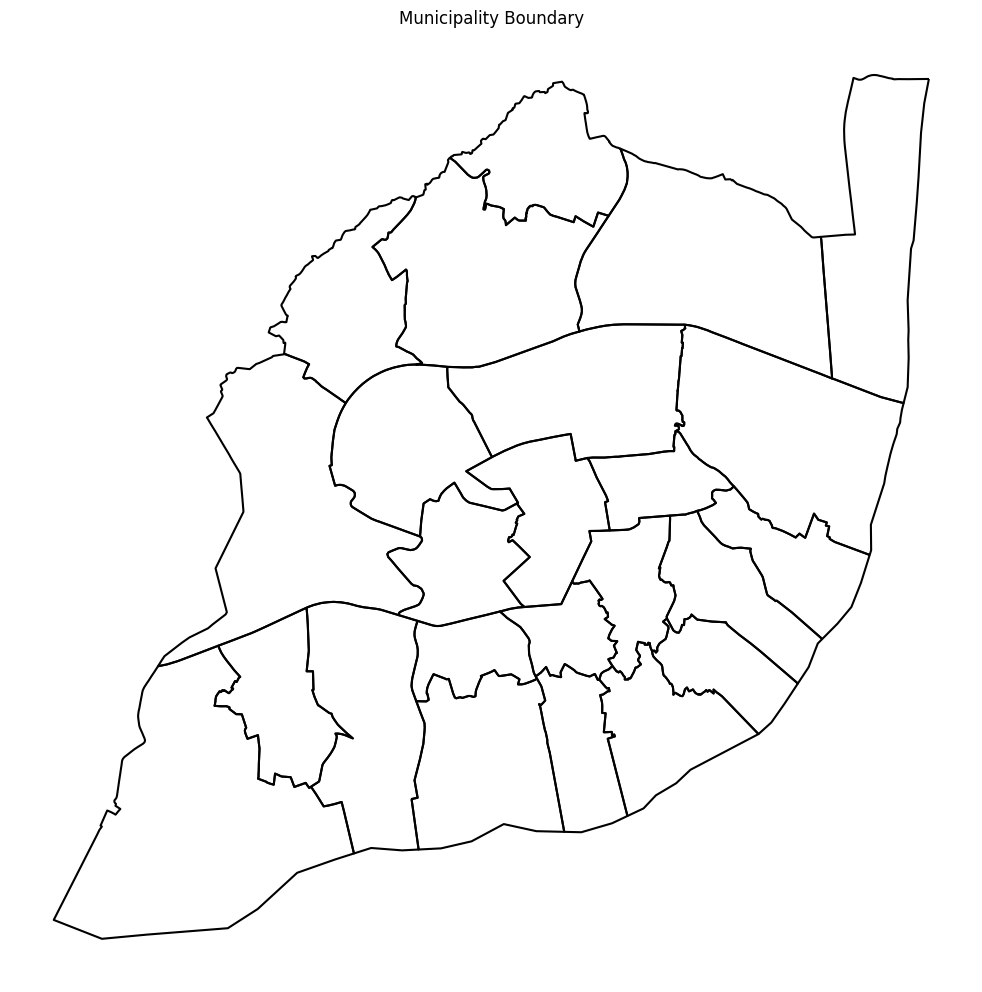

In [ ]:
# Define CRS
wgs84_crs = "EPSG:4326"  # WGS84 for geometry queries
portugal_metric_crs = "EPSG:3763"  # ETRS89 / Portugal TM06 for area calculations

# Get city boundaries
# city_gdf = ox.geocode_to_gdf("Lisbon, Portugal").to_crs(wgs84_crs)
# read from file
city_gdf = gpd.read_file(f"../data/cities/{city.lower()}_freguesias.geojson")
port_polygon = city_gdf.geometry.iloc[0]

# Visualize Porto boundary
fig, ax = plt.subplots(figsize=(10, 10))
city_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5)
ax.set_title("Municipality Boundary")
ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Define freguesias statistics (median income)

In [20]:
# Load median income data from the JSON file

# Read the data from the JSON file
with open(f"../data/socioeconomic_layer/socioeconomic_data_{city.lower()}.json", "r", encoding="utf-8") as file:
    socio_data = json.load(file)

# Extract the freguesia income data
data = {
    "name": [],
    "median_inc": []
}

# Populate the data dictionary directly from the socio_data
# The JSON structure already has name and median_inc as lists
data["name"] = socio_data["name"]
data["median_inc"] = socio_data["median_inc"]

# Create a DataFrame with the median income data
freg_stats = pd.DataFrame(data)

# Examine the data
print("\nMedian Income by freguesia:")
print(freg_stats)


Median Income by freguesia:
                       name  median_inc
0                     Ajuda       11816
1                 Alcântara       12280
2                  Alvalade       18301
3                   Areeiro       17452
4                   Arroios       10938
5            Avenidas Novas       17841
6                     Beato       10536
7                     Belém       19212
8                   Benfica       14888
9          Campo de Ourique       14629
10                Campolide       12655
11                  Carnide       15503
12                  Estrela       14787
13                   Lumiar       20777
14                  Marvila       10559
15             Misericórdia       11019
16                  Olivais       12883
17        Parque das Nações       20129
18          Penha de França       10682
19              Santa Clara       10900
20        Santa Maria Maior        9036
21            Santo António       14377
22  São Domingos de Benfica       18899
23         

In [21]:
# Filter to include only freguesias with GINI data
freg_gdf_with_data = city_gdf[
    city_gdf["fre_name"].isin(freg_stats["name"].values)
].copy()

# Merge with GINI data
freg_gdf_with_data = freg_gdf_with_data.merge(
    freg_stats, left_on="fre_name", right_on="name", how="left"
)

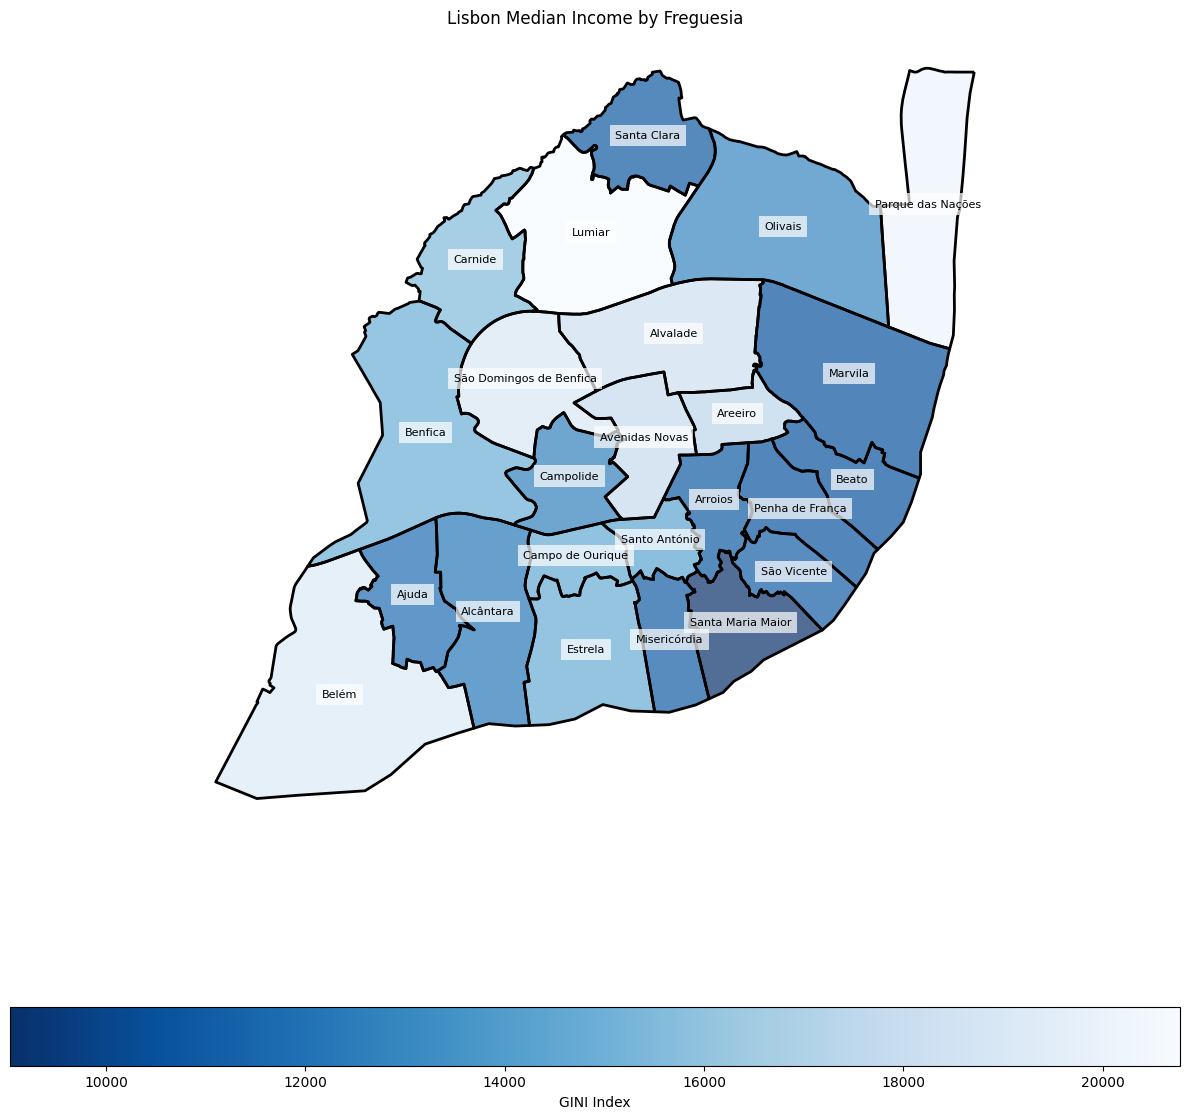

In [22]:
# Visualize freguesias with color based on GINI index
fig, ax = plt.subplots(figsize=(12, 12))
city_gdf.to_crs(portugal_metric_crs).boundary.plot(ax=ax, color="black", linewidth=2)

# Plot with color based on GINI (using blue tones)
plot = freg_gdf_with_data.to_crs(portugal_metric_crs).plot(
    ax=ax,
    column="median_inc",
    cmap="Blues_r",
    legend=True,
    edgecolor="white",
    alpha=0.7,
    legend_kwds={"label": "GINI Index", "orientation": "horizontal"},
)

# Add freguesia names
for idx, row in freg_gdf_with_data.to_crs(portugal_metric_crs).iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(
        row["name"].split(",")[0],
        xy=(x, y),
        ha="center",
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )

ax.set_title(f"{city} Median Income by Freguesia")
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Create hexagonal grid

In [23]:
# Create a hexagonal grid covering Porto using VERUS library
# Use the HexagonGridGenerator from VERUS to create a grid with 100m edge length
grid_gen = HexagonGridGenerator(region=f"../data/cities/{city.lower()}.geojson", edge_length=100)
hex_grid = grid_gen.run()

# The grid is in EPSG:4326, convert to metric CRS for analysis
hex_grid = hex_grid.to_crs(portugal_metric_crs)

print(f"Number of hexagons in the grid: {len(hex_grid)}")

2025-05-20 17:37:07 [INFO] Initialized grid generator for region from file: lisbon.geojson
2025-05-20 17:37:07 [INFO] Processing region
2025-05-20 17:37:07 [INFO] Loading region boundary from file: ../data/cities/lisbon.geojson
2025-05-20 17:37:07 [INFO] Generating hexagonal grid with edge length 100m
2025-05-20 17:37:08 [INFO] Generated 11131 hexagons
2025-05-20 17:37:08 [INFO] Assigning random values between 0 and 1
2025-05-20 17:37:08 [INFO] Assigning colors based on values
2025-05-20 17:37:08 [INFO] Clipping grid to region boundaries
2025-05-20 17:37:08 [INFO] Clipped from 11131 to 6569 hexagons
Number of hexagons in the grid: 6569


## 5. Map income values to hexagons

In [24]:
# Map GINI values from freguesias to hexagons
# Perform a spatial join to determine which freguesia each hexagon belongs to

# Ensure both datasets are in the same CRS
hex_grid_copy = hex_grid.copy()
freg_data_for_join = freg_gdf_with_data[["name", "median_inc", "geometry"]].copy()

# Make sure both datasets are in the same CRS (portugal_metric_crs)
if hex_grid_copy.crs != freg_data_for_join.crs:
    freg_data_for_join = freg_data_for_join.to_crs(hex_grid_copy.crs)

# Fix any potential invalid geometries
hex_grid_copy["geometry"] = hex_grid_copy.geometry.buffer(0)
freg_data_for_join["geometry"] = freg_data_for_join.geometry.buffer(0)

# Now perform the spatial join with aligned CRS
hex_income = gpd.sjoin(
    hex_grid_copy,
    freg_data_for_join,
    how="left",
    predicate="intersects",
).drop(columns=["index_right"], errors="ignore")

# Print diagnostic information
print(f"Total hexagons: {len(hex_income)}")
print(f"Hexagons with Median Income values: {hex_income['median_inc'].notna().sum()}")
print(f"Hexagons missing Median Income values: {hex_income['median_inc'].isna().sum()}")

# Handle hexagons that overlap multiple freguesias (take the value of the freguesia with the largest overlap)
overlap_hexagons = hex_income[hex_income.duplicated(subset=["hex_id"], keep=False)]

if not overlap_hexagons.empty:
    print(f"Found {len(overlap_hexagons)} hexagons overlapping multiple freguesias")

    # Get unique hex_ids with overlaps
    unique_overlap_ids = overlap_hexagons["hex_id"].unique()

    # For each overlapping hexagon, calculate the area of overlap with each freguesia
    for hex_id in unique_overlap_ids:
        hex_geom = hex_grid[hex_grid["hex_id"] == hex_id].geometry.iloc[0]

        max_area = 0
        max_freg_idx = None

        # Find the freguesia with the largest overlap
        for idx, freg_row in freg_gdf_with_data.iterrows():
            if hex_geom.intersects(freg_row.geometry):
                overlap_area = hex_geom.intersection(freg_row.geometry).area
                if overlap_area > max_area:
                    max_area = overlap_area
                    max_freg_idx = idx

        if max_freg_idx is not None:
            # Convert max_freg_idx to int to ensure it's a valid iloc index
            max_freg = freg_gdf_with_data.iloc[int(max_freg_idx)]

            # Remove all entries for this hexagon except one
            hex_income = hex_income[
                ~(
                    (hex_income["hex_id"] == hex_id)
                    & (hex_income["name"] != max_freg["name"])
                )
            ]

# Remove any remaining duplicates
hex_income = hex_income.drop_duplicates(subset=["hex_id"])
# Reset index
hex_income = hex_income.reset_index(drop=True)

print(f"Final hexagon grid size: {len(hex_income)}")

Total hexagons: 7446
Hexagons with Median Income values: 7446
Hexagons missing Median Income values: 0
Found 1715 hexagons overlapping multiple freguesias
Final hexagon grid size: 6569


In [25]:
# Normalize income values to a 0-1 scale for risk levels
# For income, we invert the scale: lower income = higher risk
# Define min and max values for normalization (from the data)
income_min = freg_stats["median_inc"].min()
income_max = freg_stats["median_inc"].max()

# Normalize and invert the income values (so that high risk = low income)
hex_income["median_income_norm"] = 1 - ((hex_income["median_inc"] - income_min) / (income_max - income_min))

# Clip values to ensure they're between 0 and 1
hex_income["median_income_norm"] = hex_income["median_income_norm"].clip(0, 1)

# Check for NaN values in the 'value' column before binning
nan_count = hex_income["median_income_norm"].isna().sum()

# First, handle missing values
missing = hex_income["median_income_norm"].isna().sum()
if missing > 0:
    # Fill missing values with the median value
    median_value = hex_income["median_income_norm"].median()
    hex_income["median_income_norm"].fillna(median_value, inplace=True)

# Define risk levels based on the normalized values
hex_income["median_income_level"] = pd.cut(
    hex_income["median_income_norm"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[1, 2, 3, 4, 5],
)

# Define colors based on risk level using blue tones
colors = {
    1: "#deebf7",  # Lightest blue
    2: "#9ecae1",  # Light blue
    3: "#6baed6",  # Medium blue
    4: "#3182bd",  # Dark blue
    5: "#08519c"   # Darkest blue
}
hex_income["color"] = hex_income["median_income_level"].map(colors)

# Check for missing values
missing = hex_income["median_income_norm"].isna().sum()
if missing > 0:
    print(f"Warning: {missing} hexagons have no income data")

    # Fill missing values with the median value (this is a simple approach)
    median_value = hex_income["median_income_norm"].median()
    median_risk = hex_income["median_income_level"].median()
    median_color = colors[int(median_risk)]

    hex_income["median_income_norm"].fillna(median_value, inplace=True)
    hex_income["median_income_level"].fillna(median_risk, inplace=True)
    hex_income["color"].fillna(median_color, inplace=True)

    print(
        f"Filled missing values with median: value={median_value}, median_income_level={median_risk}"
    )

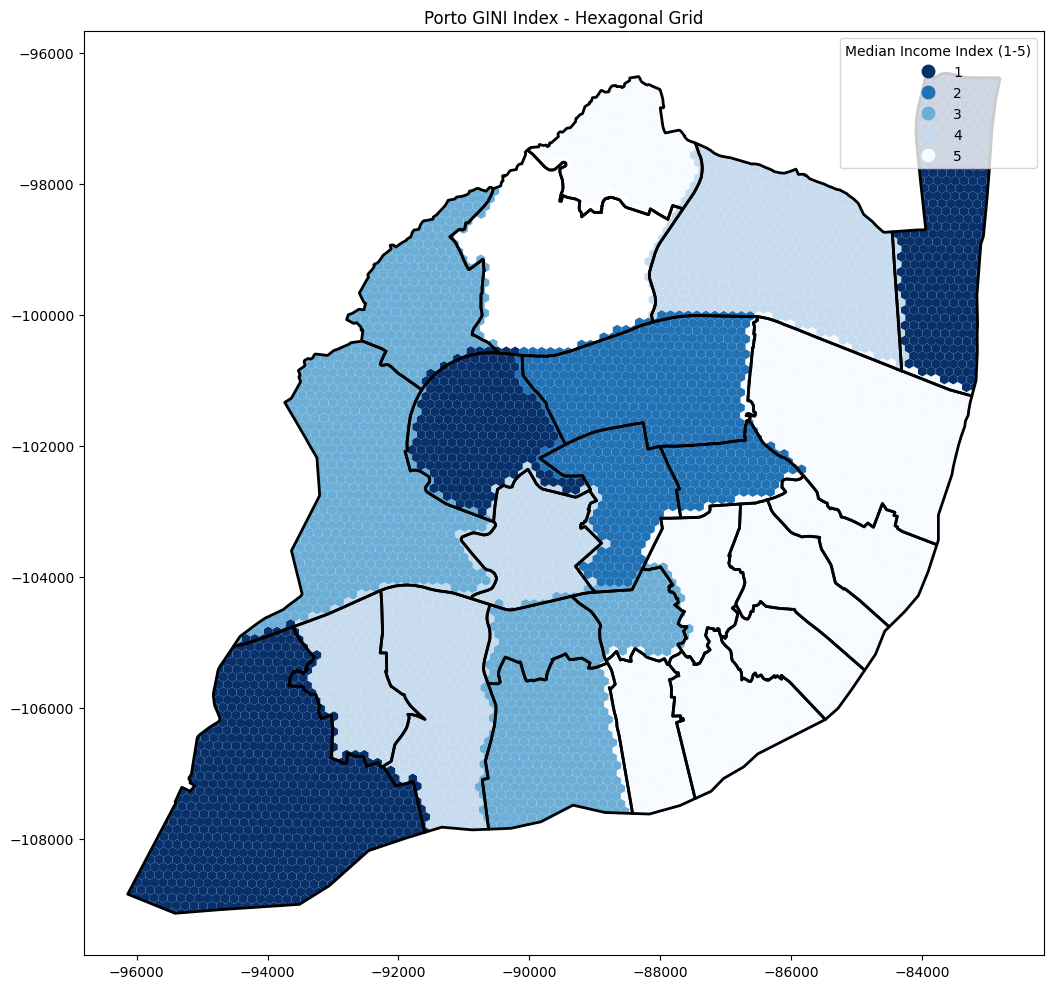

In [26]:
# Visualize the hexagonal grid with GINI values
fig, ax = plt.subplots(figsize=(12, 10))

# Make sure all geodataframes use the same CRS for plotting
hex_income_plot = hex_income.copy()
freg_plot = freg_gdf_with_data.copy()

# Ensure they all use the same metric CRS
if hex_income_plot.crs != portugal_metric_crs:
    hex_income_plot = hex_income_plot.to_crs(portugal_metric_crs)
if freg_plot.crs != portugal_metric_crs:
    freg_plot = freg_plot.to_crs(portugal_metric_crs)

# Plot hexagonal grid with GINI values
hex_income_plot.plot(
    ax=ax,
    column="median_income_level",
    categorical=True,
    legend=True,
    legend_kwds={"title": "Median Income Index (1-5)"},
    cmap="Blues_r",
)

# Plot boundaries
freg_plot.boundary.plot(ax=ax, color="black", linewidth=0.5, alpha=0.5)
city_gdf.to_crs(portugal_metric_crs).boundary.plot(ax=ax, color="black", linewidth=2)

plt.title("Porto GINI Index - Hexagonal Grid")
plt.tight_layout()
plt.show()

## 6. Save results

In [ ]:
# Convert back to EPSG:4326 for saving to GeoJSON
hex_income_4326 = hex_income.to_crs(wgs84_crs)

# Create output GeoJSON
output_geojson_path = f"../data/socioeconomic_layer/{city}_median_income.geojson"

# Select only the required columns to match the format of vulnerability/mitigation files
hex_income_output = hex_income_4326[
    ["hex_id", "median_inc", "median_income_level", "geometry"]
]

# Save to GeoJSON
hex_income_output.to_file(output_geojson_path, driver="GeoJSON")
print(f"Saved GeoJSON to {output_geojson_path}")

Saved GeoJSON to ../data/socioeconomic_layer/Lisbon_median_income.geojson
